# Modèle Ethnicité V3 - MobileNetV3Small

**Changements par rapport à V2:**

- **Backbone MobileNetV3Small** (au lieu d'EfficientNetB0)
- SE Attention conservé
- Focal Loss pour déséquilibre de classes
- Système de confiance conservé
- Mixup pour data augmentation
- Fine-tuning en 2 phases

**Avantages de MobileNetV3Small:**

- ~2.5M paramètres (vs ~5.3M pour EfficientNetB0)
- 2-3x plus rapide sur mobile
- TFLite plus petit (~6MB vs ~15MB)


In [ ]:
import os, sys, pathlib
ROOT = pathlib.Path.cwd()
if not (ROOT / 'config.py').exists():
    for parent in ROOT.parents:
        if (parent / 'config.py').exists():
            ROOT = parent
            break
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from config import (
    BASE_DIR, DATA_DIR, RAW_DIR, IMAGES_DIR, ARTIFACTS_DIR,
    NOTEBOOKS_DIR, ANDROID_ASSETS_DIR, TESTS_DIR, DIAGNOSTICS_DIR,
    ensure_kaggle_credentials, ensure_kaggle_dataset, describe_config,
    artifacts_for,
 )

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import json
import time
from PIL import Image
from pathlib import Path
import pandas as pd

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

print('Working dir set to', ROOT)
print(describe_config())


TensorFlow version: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Configuration


In [ ]:
# Chemins
DATA_DIR = IMAGES_DIR
OUTPUT_DIR = artifacts_for("ethnicity", "ethnicity_model_v3_mobilenet")
ARTIFACTS_DIR = OUTPUT_DIR

# Classes - 5 classes avec "Others"
ETHNICITY_MAP = {0: "White", 1: "Black", 2: "Asian", 3: "Indian", 4: "Others"}
NUM_CLASSES = len(ETHNICITY_MAP)
CLASS_NAMES = list(ETHNICITY_MAP.values())

# Hyperparamètres
IMG_SIZE = 128
BATCH_SIZE = 32
WARMUP_EPOCHS = 30
FINETUNE_EPOCHS = 60
INITIAL_LR = 3e-4
FINETUNE_LR = 5e-6

# Focal Loss
FOCAL_GAMMA = 3.0
FOCAL_ALPHA = 0.35

# Mixup
MIXUP_ALPHA = 0.3

# Label smoothing
LABEL_SMOOTHING = 0.15

# Seuil de confiance
CONFIDENCE_THRESHOLD = 0.35

# Validation
VAL_SPLIT = 0.1
TEST_SPLIT = 0.1

print(f"Dataset: {DATA_DIR}")
print(f"Output: {OUTPUT_DIR}")
print(f"Configuration V3 (MobileNetV3Small):")
print(f"  - Backbone: MobileNetV3Small")
print(f"  - Classes: {CLASS_NAMES}")
print(f"  - Focal Loss: gamma={FOCAL_GAMMA}, alpha={FOCAL_ALPHA}")
print(f"  - Seuil de confiance: {CONFIDENCE_THRESHOLD}")

Configuration V3 (MobileNetV3Small):
  - Backbone: MobileNetV3Small
  - Classes: ['White', 'Black', 'Asian', 'Indian', 'Others']
  - Focal Loss: gamma=3.0, alpha=0.35
  - Seuil de confiance: 0.35


## Chargement des Données


In [ ]:
def parse_utkface_filename(filepath):
    try:
        name = Path(filepath).name.split(".")[0]
        parts = name.split("_")
        if len(parts) < 3:
            return None
        ethnicity = int(parts[2]) if parts[2].isdigit() else -1
        if ethnicity < 0 or ethnicity > 4:
            return None
        return {
            "filepath": str(filepath),
            "ethnicity": ethnicity,
            "ethnicity_name": ETHNICITY_MAP.get(ethnicity, "Unknown"),
        }
    except Exception:
        return None


image_paths = list(DATA_DIR.glob("*.jpg*"))
print(f"Images trouvées: {len(image_paths)}")

records = []
for path in tqdm(image_paths, desc="Parsing"):
    record = parse_utkface_filename(path)
    if record:
        records.append(record)

df = pd.DataFrame(records)
print(f"Images valides (5 classes): {len(df)}")

# Distribution
print("\nDistribution:")
print(df["ethnicity_name"].value_counts())

Images trouvées: 23708


Parsing: 100%|██████████| 23708/23708 [00:00<00:00, 266034.28it/s]

Images valides (5 classes): 23705

Distribution:
ethnicity_name
White     10078
Black      4526
Indian     3975
Asian      3434
Others     1692
Name: count, dtype: int64


## Split et Oversampling


In [ ]:
X = df["filepath"].values
y = df["ethnicity"].values

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=TEST_SPLIT, stratify=y, random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=VAL_SPLIT / (1 - TEST_SPLIT),
    stratify=y_temp,
    random_state=SEED,
)

print(f"Split:")
print(f"  - Train: {len(X_train)}")
print(f"  - Val: {len(X_val)}")
print(f"  - Test: {len(X_test)}")

# Calculer class weights
class_weights_array = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
class_weights = {i: w for i, w in enumerate(class_weights_array)}
print(f"\nClass weights:")
for cls_id, weight in class_weights.items():
    print(f"  - {ETHNICITY_MAP[cls_id]}: {weight:.3f}")

Split:
  - Train: 18963
  - Val: 2371
  - Test: 2371

Class weights:
  - White: 0.470
  - Black: 1.048
  - Asian: 1.380
  - Indian: 1.193
  - Others: 2.801


In [5]:
def oversample_minority_classes(X, y, target_ratio=1.0):
    """Oversample les classes minoritaires."""
    unique, counts = np.unique(y, return_counts=True)
    max_count = int(counts.max() * target_ratio)

    X_resampled, y_resampled = [], []

    for cls in unique:
        mask = y == cls
        X_cls = X[mask]
        y_cls = y[mask]
        current_count = len(X_cls)

        if current_count < max_count:
            repeats = (max_count // current_count) + 1
            X_cls = np.tile(X_cls, repeats)[:max_count]
            y_cls = np.tile(y_cls, repeats)[:max_count]

        X_resampled.extend(X_cls)
        y_resampled.extend(y_cls)

    indices = np.random.permutation(len(X_resampled))
    return np.array(X_resampled)[indices], np.array(y_resampled)[indices]


X_train_balanced, y_train_balanced = oversample_minority_classes(X_train, y_train)
print(f"\nAprès oversampling: {len(X_train_balanced)} (était {len(X_train)})")


Après oversampling: 40310 (était 18963)


## Focal Loss


In [ ]:
class FocalLoss(keras.losses.Loss):
    """Focal Loss pour classification multi-classe."""

    def __init__(
        self, gamma=2.0, alpha=0.25, label_smoothing=0.0, class_weights=None, **kwargs
    ):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha
        self.label_smoothing = label_smoothing
        self.class_weights = class_weights

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        num_classes = tf.shape(y_pred)[-1]

        if len(y_true.shape) == 1:
            y_true = tf.one_hot(y_true, depth=num_classes)

        y_true = tf.cast(y_true, tf.float32)

        if self.label_smoothing > 0:
            num_classes_float = tf.cast(num_classes, tf.float32)
            y_true = y_true * (1.0 - self.label_smoothing) + (
                self.label_smoothing / num_classes_float
            )

        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        cross_entropy = -y_true * tf.math.log(y_pred)

        p_t = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
        focal_weight = tf.pow(1.0 - p_t, self.gamma)

        if self.class_weights is not None:
            weights_tensor = tf.constant(
                [self.class_weights.get(i, 1.0) for i in range(5)], dtype=tf.float32
            )
            class_weight_factor = tf.reduce_sum(
                y_true * weights_tensor, axis=-1, keepdims=True
            )
            focal_loss = self.alpha * focal_weight * class_weight_factor * cross_entropy
        else:
            focal_loss = self.alpha * focal_weight * cross_entropy

        return tf.reduce_mean(tf.reduce_sum(focal_loss, axis=-1))

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "gamma": self.gamma,
                "alpha": self.alpha,
                "label_smoothing": self.label_smoothing,
                "class_weights": self.class_weights,
            }
        )
        return config


print("Focal Loss définie!")

Focal Loss définie!


## Data Pipeline avec Mixup


In [ ]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.25),
        layers.RandomZoom((-0.15, 0.15)),
        layers.RandomTranslation(0.12, 0.12),
        layers.RandomBrightness(0.25),
        layers.RandomContrast(0.25),
    ],
    name="data_augmentation",
)


def load_and_preprocess(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img, label


def mixup(images, labels, alpha=0.2):
    """Mixup augmentation."""
    batch_size = tf.shape(images)[0]
    lam = tf.random.uniform([], 0, 1)
    if alpha > 0:
        lam = tf.maximum(lam, 1 - lam)
    indices = tf.random.shuffle(tf.range(batch_size))
    mixed_images = lam * images + (1 - lam) * tf.gather(images, indices)
    labels_one_hot = tf.one_hot(labels, NUM_CLASSES)
    mixed_labels = lam * labels_one_hot + (1 - lam) * tf.gather(labels_one_hot, indices)
    return mixed_images, mixed_labels


def create_dataset(
    filepaths, labels, batch_size, shuffle=True, augment=False, use_mixup=False
):
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(filepaths), seed=SEED, reshuffle_each_iteration=True
        )

    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)

    if augment:
        ds = ds.map(
            lambda x, y: (data_augmentation(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE,
        )

    if use_mixup:
        ds = ds.map(
            lambda x, y: mixup(x, y, MIXUP_ALPHA),
            num_parallel_calls=tf.data.AUTOTUNE,
        )

    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = create_dataset(
    X_train_balanced,
    y_train_balanced,
    BATCH_SIZE,
    shuffle=True,
    augment=True,
    use_mixup=True,
)
val_ds = create_dataset(
    X_val, y_val, BATCH_SIZE, shuffle=False, augment=False, use_mixup=False
)
test_ds = create_dataset(
    X_test, y_test, BATCH_SIZE, shuffle=False, augment=False, use_mixup=False
)

print("Datasets créés avec Mixup!")

I0000 00:00:1769589177.415765   42161 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4089 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Datasets créés avec Mixup!


## Modèle avec SE Attention + MobileNetV3Small


In [ ]:
def squeeze_excitation_block(x, ratio=16, name_prefix="se"):
    """Squeeze-Excitation attention block."""
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling2D(name=f"{name_prefix}_gap")(x)
    se = layers.Dense(filters // ratio, activation="relu", name=f"{name_prefix}_fc1")(
        se
    )
    se = layers.Dense(filters, activation="sigmoid", name=f"{name_prefix}_fc2")(se)
    se = layers.Reshape((1, 1, filters), name=f"{name_prefix}_reshape")(se)
    return layers.Multiply(name=f"{name_prefix}_scale")([x, se])


def build_ethnicity_model_v3(img_size, num_classes, trainable_backbone=False):
    """
    Modèle V3 avec MobileNetV3Small + SE attention.

    Changement: EfficientNetB0 -> MobileNetV3Small
    """
    inputs = layers.Input(shape=(img_size, img_size, 3), name="input_image")

    # ════════════════════════════════════════════════════════════
    # BACKBONE: MobileNetV3Small
    # ════════════════════════════════════════════════════════════
    backbone = MobileNetV3Small(
        include_top=False,
        weights="imagenet",
        input_shape=(img_size, img_size, 3),
        include_preprocessing=True,
        pooling=None,
    )
    backbone.trainable = trainable_backbone

    x = backbone(inputs)

    # SE attention
    x = squeeze_excitation_block(x, ratio=16, name_prefix="se")

    # Double pooling
    gap = layers.GlobalAveragePooling2D(name="gap")(x)
    gmp = layers.GlobalMaxPooling2D(name="gmp")(x)
    x = layers.Concatenate(name="concat_pool")([gap, gmp])

    # Head
    x = layers.Dense(
        512, kernel_regularizer=regularizers.l2(1e-4), name="head_dense_1"
    )(x)
    x = layers.BatchNormalization(name="head_bn_1")(x)
    x = layers.Activation("relu", name="head_relu_1")(x)
    x = layers.Dropout(0.5, name="head_dropout_1")(x)

    x = layers.Dense(
        256, kernel_regularizer=regularizers.l2(1e-4), name="head_dense_2"
    )(x)
    x = layers.BatchNormalization(name="head_bn_2")(x)
    x = layers.Activation("relu", name="head_relu_2")(x)
    x = layers.Dropout(0.4, name="head_dropout_2")(x)

    x = layers.Dense(
        128, kernel_regularizer=regularizers.l2(1e-4), name="head_dense_3"
    )(x)
    x = layers.BatchNormalization(name="head_bn_3")(x)
    x = layers.Activation("relu", name="head_relu_3")(x)
    x = layers.Dropout(0.3, name="head_dropout_3")(x)

    outputs = layers.Dense(num_classes, activation="softmax", name="ethnicity_output")(
        x
    )

    model = Model(inputs, outputs, name="EthnicityModel_V3_MobileNet")
    return model, backbone


model, backbone = build_ethnicity_model_v3(
    IMG_SIZE, NUM_CLASSES, trainable_backbone=False
)

print(f"\n{'='*60}")
print(f"MODÈLE ETHNICITÉ V3 - MobileNetV3Small")
print(f"{'='*60}")
print(f"Backbone: MobileNetV3Small ({len(backbone.layers)} couches)")
print(f"Total params: {model.count_params():,}")
model.summary()


MODÈLE ETHNICITÉ V3 - MobileNetV3Small
Backbone: MobileNetV3Small (157 couches)
Total params: 1,739,993


Model: "EthnicityModel_V3_MobileNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MobileNetV3Small    │ (None, 4, 4, 576) │    939,120 │ input_image[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se_gap              │ (None, 576)       │          0 │ MobileNetV3Small… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se_fc1 (Dense)      │ (None, 36)        │     20,772 │ se_gap[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se_fc2 (Dense)      │ (None, 576)       │     21,312 │ se_fc1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se_reshape          │ (None, 1, 1, 576) │          0 │ se_fc2[0][0]      │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se_scale (Multiply) │ (None, 4, 4, 576) │          0 │ MobileNetV3Small… │
│                     │                   │            │ se_reshape[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 576)       │          0 │ se_scale[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gmp                 │ (None, 576)       │          0 │ se_scale[0][0]    │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_pool         │ (None, 1152)      │          0 │ gap[0][0],        │
│ (Concatenate)       │                   │            │ gmp[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dense_1        │ (None, 512)       │    590,336 │ concat_pool[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_bn_1           │ (None, 512)       │      2,048 │ head_dense_1[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_relu_1         │ (None, 512)       │          0 │ head_bn_1[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dropout_1      │ (None, 512)       │          0 │ head_relu_1[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dense_2        │ (None, 256)       │    131,328 │ head_dropout_1[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_bn_2           │ (None, 256)       │      1,024 │ head_dense_2[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_relu_2         │ (None, 256)       │          0 │ head_bn_2[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,739,993 (6.64 MB)

 Trainable params: 799,081 (3.05 MB)

 Non-trainable params: 940,912 (3.59 MB)

## Phase 1: Warmup


In [ ]:
steps_per_epoch = len(X_train_balanced) // BATCH_SIZE
total_warmup_steps = steps_per_epoch * WARMUP_EPOCHS

warmup_lr_schedule = CosineDecay(
    initial_learning_rate=INITIAL_LR,
    decay_steps=total_warmup_steps,
    alpha=0.1,
)

focal_loss = FocalLoss(
    gamma=FOCAL_GAMMA,
    alpha=FOCAL_ALPHA,
    label_smoothing=LABEL_SMOOTHING,
    class_weights=class_weights,
)

model.compile(
    optimizer=AdamW(learning_rate=warmup_lr_schedule, weight_decay=1e-4),
    loss=focal_loss,
    metrics=["accuracy"],
)

warmup_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=15,
        restore_best_weights=True,
        mode="max",
        verbose=1,
    ),
    callbacks.ModelCheckpoint(
        filepath=str(ARTIFACTS_DIR / "ethnicity_v3_mobilenet_warmup.keras"),
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1,
    ),
]

print(f"Phase 1: Warmup ({WARMUP_EPOCHS} epochs, backbone gelé)")

Phase 1: Warmup (30 epochs, backbone gelé)


In [10]:
warmup_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=WARMUP_EPOCHS,
    callbacks=warmup_callbacks,
    verbose=1,
)

Epoch 1/30
   1/1260 ━━━━━━━━━━━━━━━━━━━━ 6:13:40 18s/step - accuracy: 0.0938 - loss: 0.2896

I0000 00:00:1769589197.009081   43182 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1260/1260 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2324 - loss: 0.2485
Epoch 1: val_accuracy improved from None to 0.07423, saving model to /home/optimalako/Projet/SAE/artifacts/ethnicity_v3_mobilenet_warmup.keras

Epoch 1: finished saving model to /home/optimalako/Projet/SAE/artifacts/ethnicity_v3_mobilenet_warmup.keras
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 65s 37ms/step - accuracy: 0.2544 - loss: 0.2297 - val_accuracy: 0.0742 - val_loss: 0.3998
Epoch 2/30
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2936 - loss: 0.2002
Epoch 2: val_accuracy did not improve from 0.07423
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.2944 - loss: 0.1958 - val_accuracy: 0.0696 - val_loss: 0.3670
Epoch 3/30
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3141 - loss: 0.1766
Epoch 3: val_accuracy did not improve from 0.07423
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.3202 - loss: 0.1720 - val_accuracy: 0.0704 - val_loss: 0.3339
Epoch 4/30
1259/1260 ━━━━━━

## Phase 2: Fine-tuning


In [ ]:
backbone.trainable = True

# MobileNetV3Small a ~158 couches, on en dégèle 50
freeze_until = len(backbone.layers) - 50
for layer in backbone.layers[:freeze_until]:
    layer.trainable = False

trainable_count = sum(
    [tf.reduce_prod(w.shape).numpy() for w in model.trainable_weights]
)
print(f"Phase 2: Fine-tuning ({FINETUNE_EPOCHS} epochs)")
print(f"Couches dégelées: {len(backbone.layers) - freeze_until}/{len(backbone.layers)}")
print(f"Paramètres entraînables: {trainable_count:,}")

Phase 2: Fine-tuning (60 epochs)
Couches dégelées: 50/157
Paramètres entraînables: 1,535,665


In [ ]:
total_finetune_steps = steps_per_epoch * FINETUNE_EPOCHS

finetune_lr_schedule = CosineDecay(
    initial_learning_rate=FINETUNE_LR,
    decay_steps=total_finetune_steps,
    alpha=0.01,
)

model.compile(
    optimizer=AdamW(learning_rate=finetune_lr_schedule, weight_decay=1e-4),
    loss=focal_loss,
    metrics=["accuracy"],
)

finetune_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=20,
        restore_best_weights=True,
        mode="max",
        verbose=1,
    ),
    callbacks.ModelCheckpoint(
        filepath=str(ARTIFACTS_DIR / "ethnicity_v3_mobilenet_best.keras"),
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1,
    ),
]

In [13]:
finetune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINETUNE_EPOCHS,
    callbacks=finetune_callbacks,
    verbose=1,
)

Epoch 1/60
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3625 - loss: 0.0938
Epoch 1: val_accuracy improved from None to 0.07465, saving model to /home/optimalako/Projet/SAE/artifacts/ethnicity_v3_mobilenet_best.keras

Epoch 1: finished saving model to /home/optimalako/Projet/SAE/artifacts/ethnicity_v3_mobilenet_best.keras
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 57s 32ms/step - accuracy: 0.3687 - loss: 0.0926 - val_accuracy: 0.0747 - val_loss: 0.2525
Epoch 2/60
1258/1260 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3794 - loss: 0.0891
Epoch 2: val_accuracy improved from 0.07465 to 0.08056, saving model to /home/optimalako/Projet/SAE/artifacts/ethnicity_v3_mobilenet_best.keras

Epoch 2: finished saving model to /home/optimalako/Projet/SAE/artifacts/ethnicity_v3_mobilenet_best.keras
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - accuracy: 0.3803 - loss: 0.0894 - val_accuracy: 0.0806 - val_loss: 0.2432
Epoch 3/60
1258/1260 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3893 - loss:

## Évaluation


In [ ]:
best_model = keras.models.load_model(
    ARTIFACTS_DIR / "ethnicity_v3_mobilenet_best.keras",
    custom_objects={"FocalLoss": FocalLoss},
)

# Prédictions
y_pred_proba = best_model.predict(test_ds, verbose=1)
y_pred_simple = np.argmax(y_pred_proba, axis=1)
y_true = y_test


def predict_with_confidence(proba, threshold):
    """Prédit avec système de confiance."""
    max_proba = np.max(proba, axis=1)
    predictions = np.argmax(proba, axis=1)
    low_confidence_mask = max_proba < threshold
    predictions[low_confidence_mask] = 4  # Others
    return predictions, max_proba


y_pred_conf, confidence_scores = predict_with_confidence(
    y_pred_proba, CONFIDENCE_THRESHOLD
)

# Métriques
accuracy_simple = np.mean(y_pred_simple == y_true)
f1_macro_simple = f1_score(y_true, y_pred_simple, average="macro")

accuracy_conf = np.mean(y_pred_conf == y_true)
f1_macro_conf = f1_score(y_true, y_pred_conf, average="macro")

print(f"\n{'='*60}")
print(f"RÉSULTATS V3 (MobileNetV3Small) SUR LE TEST SET")
print(f"{'='*60}")
print(f"\n--- Sans système de confiance ---")
print(f"  - Accuracy: {accuracy_simple:.4f} ({accuracy_simple*100:.2f}%)")
print(f"  - F1 Score (macro): {f1_macro_simple:.4f}")

print(f"\n--- Avec système de confiance (seuil={CONFIDENCE_THRESHOLD}) ---")
print(f"  - Accuracy: {accuracy_conf:.4f} ({accuracy_conf*100:.2f}%)")
print(f"  - F1 Score (macro): {f1_macro_conf:.4f}")

75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step

RÉSULTATS V3 (MobileNetV3Small) SUR LE TEST SET

--- Sans système de confiance ---
  - Accuracy: 0.4213 (42.13%)
  - F1 Score (macro): 0.4128

--- Avec système de confiance (seuil=0.35) ---
  - Accuracy: 0.3248 (32.48%)
  - F1 Score (macro): 0.3466


In [ ]:
print("\nRapport de classification (sans système de confiance):")
print(
    classification_report(
        y_true, y_pred_simple, target_names=CLASS_NAMES, zero_division=0
    )
)


Rapport de classification (sans système de confiance):
              precision    recall  f1-score   support

       White       0.89      0.43      0.58      1008
       Black       0.79      0.45      0.57       453
       Asian       0.43      0.48      0.45       343
      Indian       0.42      0.18      0.26       398
      Others       0.12      0.76      0.21       169

    accuracy                           0.42      2371
   macro avg       0.53      0.46      0.41      2371
weighted avg       0.67      0.42      0.48      2371



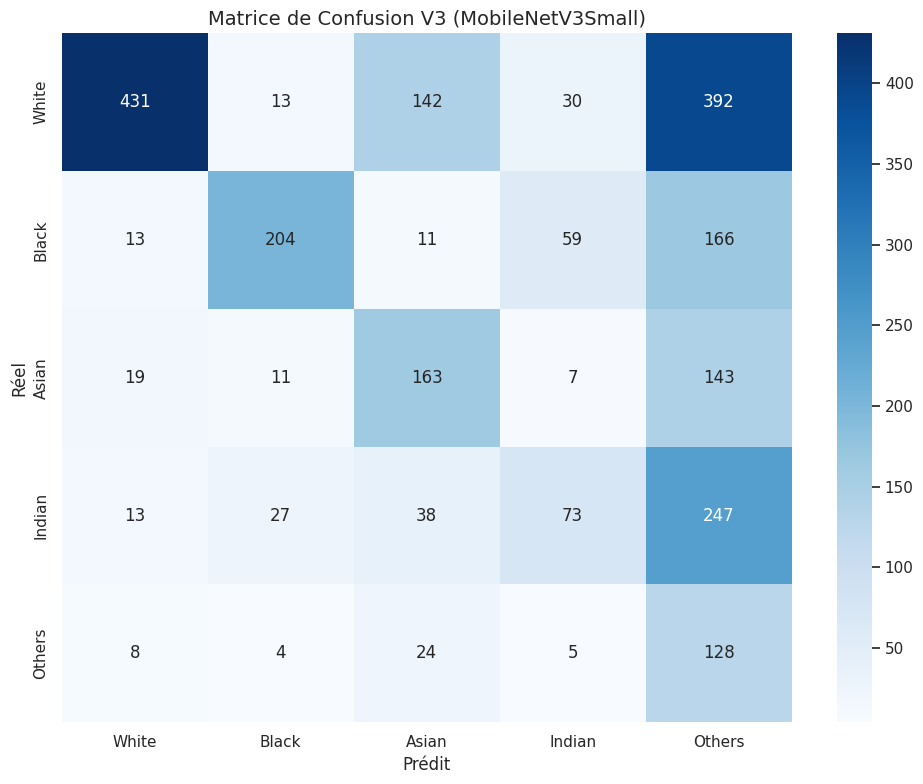

In [16]:
# Matrice de confusion
cm = confusion_matrix(y_true, y_pred_simple)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    annot_kws={"size": 12},
)
ax.set_xlabel("Prédit")
ax.set_ylabel("Réel")
ax.set_title(f"Matrice de Confusion V3 (MobileNetV3Small)")

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "ethnicity_v3_mobilenet_confusion.png", dpi=150)
plt.show()

## Sauvegarde et Conversion TFLite


In [17]:
final_model_path = ARTIFACTS_DIR / "ethnicity_v3_mobilenet_final.keras"
best_model.save(final_model_path)
print(f"Modèle sauvegardé: {final_model_path}")

import json

model_info = {
    "version": "3.0",
    "backbone": "MobileNetV3Small",
    "img_size": IMG_SIZE,
    "num_classes": NUM_CLASSES,
    "classes": CLASS_NAMES,
    "class_map": {str(k): v for k, v in ETHNICITY_MAP.items()},
    "input_range": [0, 255],
    "confidence_threshold": CONFIDENCE_THRESHOLD,
    "features": [
        "MobileNetV3Small backbone",
        "5 classes avec Others",
        "Système de confiance",
        "Focal Loss",
        "Mixup",
        "SE Attention",
    ],
    "metrics": {
        "accuracy_simple": float(accuracy_simple),
        "accuracy_with_confidence": float(accuracy_conf),
        "f1_macro_simple": float(f1_macro_simple),
        "f1_macro_with_confidence": float(f1_macro_conf),
    },
}

with open(ARTIFACTS_DIR / "ethnicity_v3_mobilenet_info.json", "w") as f:
    json.dump(model_info, f, indent=2)
print("Infos du modèle sauvegardées")

Modèle sauvegardé: /home/optimalako/Projet/SAE/artifacts/ethnicity_v3_mobilenet_final.keras
Infos du modèle sauvegardées


In [18]:
# Conversion TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_model = converter.convert()

tflite_path = ARTIFACTS_DIR / "ethnicity_v3_mobilenet.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

tflite_size_mb = tflite_path.stat().st_size / 1024 / 1024
print(f"Modèle TFLite sauvegardé: {tflite_path}")
print(f"Taille: {tflite_size_mb:.2f} MB")

INFO:tensorflow:Assets written to: /tmp/tmp7rarjiud/assets


INFO:tensorflow:Assets written to: /tmp/tmp7rarjiud/assets


Saved artifact at '/tmp/tmp7rarjiud'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  130892823286928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130890678822352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130890678822160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130890678820816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130890678822736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130890678823120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130890678823312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130890678822544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130890678822928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130890678823888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130890678820432

W0000 00:00:1769590567.813922   42161 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1769590567.813962   42161 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1769590567.876377   42161 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


## Résumé Final


In [19]:
print("=" * 60)
print("RÉSUMÉ DU MODÈLE ETHNICITÉ V3 (MobileNetV3Small)")
print("=" * 60)
print(f"\nArchitecture: MobileNetV3Small + SE Attention + Dense Head")
print(f"Input size: {IMG_SIZE}x{IMG_SIZE}x3")
print(f"Classes: {CLASS_NAMES}")
print(f"Seuil de confiance: {CONFIDENCE_THRESHOLD}")
print(f"\nPerformances sur le test set:")
print(f"  - Accuracy (simple): {accuracy_simple:.4f} ({accuracy_simple*100:.2f}%)")
print(f"  - F1 Score (macro): {f1_macro_simple:.4f}")
print(f"\nTaille TFLite: {tflite_size_mb:.2f} MB")
print(f"\nFichiers sauvegardés:")
print(f"  - {final_model_path}")
print(f"  - {tflite_path}")
print("=" * 60)

RÉSUMÉ DU MODÈLE ETHNICITÉ V3 (MobileNetV3Small)

Architecture: MobileNetV3Small + SE Attention + Dense Head
Input size: 128x128x3
Classes: ['White', 'Black', 'Asian', 'Indian', 'Others']
Seuil de confiance: 0.35

Performances sur le test set:
  - Accuracy (simple): 0.4213 (42.13%)
  - F1 Score (macro): 0.4128

Taille TFLite: 3.35 MB

Fichiers sauvegardés:
  - /home/optimalako/Projet/SAE/artifacts/ethnicity_v3_mobilenet_final.keras
  - /home/optimalako/Projet/SAE/artifacts/ethnicity_v3_mobilenet.tflite
